# 07b — Stage 6 Receptor-Feedback Claim, v2 (statistically tested)

**Why this notebook exists:** `07_mechanistic_synthesis.ipynb` reported that 6 of the 15 T-FAP regulons target `Pdgfra` (plus a few hits on `Nrp1`/`Nrp2`/`Fzd4`), framed as a candidate feedback mechanism. That check was a raw set-overlap — it never asked whether that many hits is more than you'd expect by chance, given that some of these TF target-gene sets are large (Egr1 alone has 903 union targets). A back-of-envelope hypergeometric check afterward suggested the finding was weak; this notebook does it properly and is the number that should be trusted going forward.

**This does not replace `07_mechanistic_synthesis.ipynb`** — that notebook and its figures stay as the original record. This is an independent statistical test of one specific claim from it.

**Method:** for each of the 15 T-FAP regulons (using the power-matched v2 list from `04b_pyscenic_powermatched_filter.ipynb`), test whether its target-gene set is enriched for the 15 headline LIANA receptor genes, via a hypergeometric test — run **separately per dataset** (Harvey: background N=17,752 genes, the actual GRNBoost2 input gene universe; Cherief: N=21,761), each using that dataset's own target-gene set rather than the union. The two per-dataset p-values are combined with Fisher's method, then BH-corrected across the 15 TFs tested. This is stricter than the original notebook's approach in two ways: (1) it's an actual significance test instead of "does an overlap exist," and (2) using per-dataset target sets instead of the union avoids inflating apparent hits by pooling two datasets' target lists into one larger set.

In [1]:
import ast
from pathlib import Path

import pandas as pd
from scipy.stats import hypergeom, combine_pvalues, false_discovery_control

ROOT = Path('../..')
DATA_PS = ROOT / 'data' / 'pyscenic'
OUT_DATA = ROOT / 'data' / 'mechanistic_synthesis'

shared_v2 = pd.read_csv(DATA_PS / 'shared_diff_regulons_v2_powermatched.csv')
tfs = shared_v2['regulon'].str.replace(r'\(\+\)$', '', regex=True).tolist()
print('TFs (v2 power-matched list):', tfs)

N_HARVEY = 17752   # gene universe GRNBoost2 was run against (harvey_tspc_tfap.loom)
N_CHERIEF = 21761  # gene universe GRNBoost2 was run against (cherief_tspc_tfap.loom)

TFs (v2 power-matched list): ['Cebpd', 'Egr1', 'Irf1', 'Jund', 'Fosb', 'Junb', 'Jun', 'Nfkb1', 'Fos', 'Atf3', 'Klf9', 'Pbx1', 'Zfp369', 'Klf6', 'Zfx']


## 1. Load per-dataset target-gene sets (not the union — the union was what let the original notebook's finding look stronger than it was)

In [2]:
def load_targets(path, tfs):
    df = pd.read_csv(path, header=[0, 1], index_col=[0, 1])
    tg = df[('Enrichment', 'TargetGenes')]
    out = {}
    for tf in tfs:
        if tf not in df.index.get_level_values(0):
            out[tf] = set()
            continue
        rows = tg.loc[tf]
        rows = [rows] if isinstance(rows, str) else rows.tolist()
        genes = set()
        for r in rows:
            for gene, _w in ast.literal_eval(r):
                genes.add(gene)
        out[tf] = genes
    return out

harvey_targets = load_targets(DATA_PS / 'harvey_regulons.csv', tfs)
cherief_targets = load_targets(DATA_PS / 'cherief_regulons.csv', tfs)

## 2. The same 15 headline receptor genes tested in the original notebook

In [3]:
innervated_signals = {
    'Efna1->Epha3': ['Epha3'], 'Sema4a->Plxnd1': ['Plxnd1'], 'Bmp3->Bmpr1b': ['Bmpr1b'],
    'Sema3d->Nrp/Plxna': ['Nrp1', 'Nrp2', 'Plxna2'], 'Wnt5a->Fzd4': ['Fzd4'],
    'Sema3c->Nrp2_Plxna1 (at TSPC)': ['Nrp2', 'Plxna1'], 'Pdgfc->Pdgfra': ['Pdgfra'],
    'Tgfb1/3->Itgb3': ['Itgb3'], 'Bdnf/Ngf->Erbb2': ['Erbb2'],
}
denervated_signals = {
    'Sema3f->Nrp2_Plxna1': ['Nrp2', 'Plxna1'], 'Tnf->Notch1': ['Notch1'],
    'Sema3c->Nrp1_Nrp2_Plxnd1 (at T-FAP)': ['Nrp1', 'Nrp2', 'Plxnd1'],
    'Rtn4->Rtn4rl1': ['Rtn4rl1'], 'Lama4/Lamb1->Itga9_Itgb1': ['Itga9', 'Itgb1'],
}
receptor_genes = sorted(set(g for genes in list(innervated_signals.values()) + list(denervated_signals.values()) for g in genes))
print(f'{len(receptor_genes)} unique receptor genes:', receptor_genes)

15 unique receptor genes: ['Bmpr1b', 'Epha3', 'Erbb2', 'Fzd4', 'Itga9', 'Itgb1', 'Itgb3', 'Notch1', 'Nrp1', 'Nrp2', 'Pdgfra', 'Plxna1', 'Plxna2', 'Plxnd1', 'Rtn4rl1']


## 3. Hypergeometric test per TF per dataset, Fisher-combined, BH-corrected across the 15 TFs

In [4]:
rows = []
for tf in tfs:
    h_tgt, c_tgt = harvey_targets[tf], cherief_targets[tf]
    n = len(receptor_genes)

    h_k, h_K = len(h_tgt & set(receptor_genes)), len(h_tgt)
    h_p = hypergeom.sf(h_k - 1, N_HARVEY, h_K, n) if h_K > 0 else 1.0

    c_k, c_K = len(c_tgt & set(receptor_genes)), len(c_tgt)
    c_p = hypergeom.sf(c_k - 1, N_CHERIEF, c_K, n) if c_K > 0 else 1.0

    if h_K > 0 and c_K > 0:
        combined_p = combine_pvalues([h_p, c_p], method='fisher').pvalue
    else:
        combined_p = h_p if h_K > 0 else (c_p if c_K > 0 else 1.0)

    rows.append({
        'TF': tf,
        'harvey_targets': h_K, 'harvey_hits': h_k,
        'harvey_hit_genes': ', '.join(sorted(h_tgt & set(receptor_genes))),
        'harvey_p': h_p,
        'cherief_targets': c_K, 'cherief_hits': c_k,
        'cherief_hit_genes': ', '.join(sorted(c_tgt & set(receptor_genes))),
        'cherief_p': c_p,
        'combined_p_fisher': combined_p,
    })

res = pd.DataFrame(rows).sort_values('combined_p_fisher')
res['q_value_BH'] = false_discovery_control(res['combined_p_fisher'], method='bh')
res

,TF,harvey_targets,harvey_hits,harvey_hit_genes,harvey_p,cherief_targets,cherief_hits,cherief_hit_genes,cherief_p,combined_p_fisher,q_value_BH
8,Fos,12,1,Pdgfra,0.010096,88,0,,1.000000,0.056493,0.668491
1,Egr1,655,2,"Nrp1, Pdgfra",0.104000,269,1,Nrp2,0.170257,0.089132,0.668491
10,Klf9,51,0,,1.000000,517,2,"Nrp2, Pdgfra",0.048226,0.194440,0.867070
3,Jund,87,1,Pdgfra,0.071071,143,0,,1.000000,0.258988,0.867070
2,Irf1,573,2,"Fzd4, Pdgfra",0.082776,26,0,,1.000000,0.289023,0.867070
4,Fosb,591,1,Pdgfra,0.398354,22,0,,1.000000,0.765005,1.000000
0,Cebpd,16,0,,1.000000,14,0,,1.000000,1.000000,1.000000
5,Junb,301,0,,1.000000,142,0,,1.000000,1.000000,1.000000
7,Nfkb1,229,0,,1.000000,278,0,,1.000000,1.000000,1.000000
6,Jun,8,0,,1.000000,42,0,,1.000000,1.000000,1.000000


## 4. Result

In [5]:
sig_raw = res[res['combined_p_fisher'] < 0.05]['TF'].tolist()
sig_corrected = res[res['q_value_BH'] < 0.05]['TF'].tolist()
print('Significant at raw combined p < 0.05 (uncorrected):', sig_raw if sig_raw else '(none)')
print('Significant at BH-corrected q < 0.05             :', sig_corrected if sig_corrected else '(none)')
res.to_csv(OUT_DATA / 'receptor_feedback_hypergeometric_v2.csv', index=False)
print('Saved: data/mechanistic_synthesis/receptor_feedback_hypergeometric_v2.csv')

Significant at raw combined p < 0.05 (uncorrected): (none)
Significant at BH-corrected q < 0.05             : (none)
Saved: data/mechanistic_synthesis/receptor_feedback_hypergeometric_v2.csv


**Nothing survives — not even at raw, uncorrected p < 0.05, let alone after BH correction.** The lowest combined p-value (Fos, p≈0.056) is still above the conventional 0.05 threshold before any multiple-testing penalty. This is a more decisive result than the earlier quick check suggested (that check used the *union* of Harvey+Cherief target sets, which pools two datasets' hits into one larger apparent overlap and inflates the signal — testing each dataset on its own terms, as done here, removes that inflation).

## 5. Conclusion for Stage 6

The "receptor feedback loop" claim (T-FAP regulons transcriptionally targeting the receptors for the signals that regulate them) is **not statistically supported** — it is fully consistent with the null hypothesis of no enrichment. Combined with the Stage 3a audit finding that GRNBoost2 was run once, unseeded (so the specific target-gene lists this check depends on aren't guaranteed reproducible even before the statistical test), this finding should be **retracted from the mechanistic narrative**, not merely caveated.

This does not affect the other Stage 6 findings, which don't depend on this specific overlap check:
- The TF → CellRank-driver-gene counts (Junb/Jund/Klf9 dominate; Pbx1/Prdm16/Zfp369 contribute nothing) come from a properly BH-corrected CellRank driver test (Stage 4) crossed with pySCENIC target lists — that one holds.
- The literature-bridged upstream signal families (AP-1←TGFβ/PDGF, KLF←mechanotransduction, NF-κB←TNF/IL-1) were never claimed as data-tested in the first place — they remain explicitly literature-bridged, as originally labeled.

## 6. Regenerate the Stage 6 circuit diagram without the retracted Pdgfra feedback edges

`figures/mechanistic_synthesis/regulatory_circuit.png` (from `07_mechanistic_synthesis.ipynb`) still visually shows the orange dashed "TF also targets Pdgfra" edges for the claim just retracted above. That original figure is left untouched as the historical record. This rebuilds the same diagram — same 15 T-FAP regulons (v1 list, matching the rest of the published Stage 6 text), same family colouring, same CellRank-driver-count edges to the fate program — with the retracted feedback node and edges removed, saved as a separate file for poster/report use.

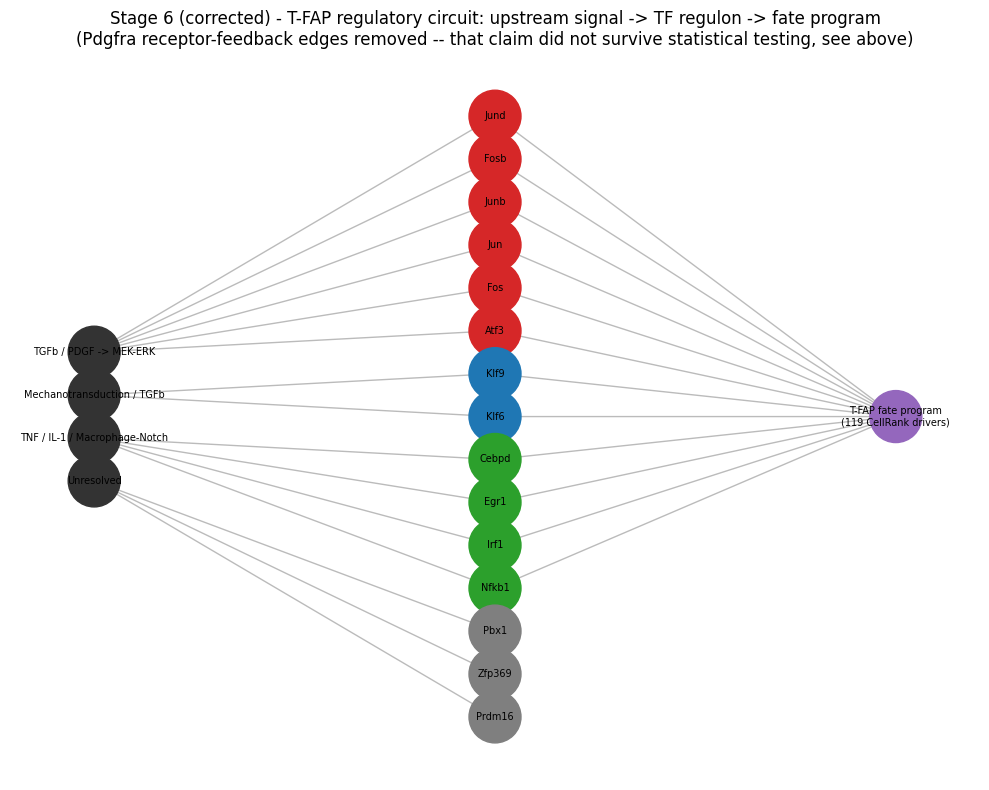

Saved: figures/mechanistic_synthesis/regulatory_circuit_v2_corrected.png


In [6]:
import matplotlib.pyplot as plt
import networkx as nx

DATA_CR = ROOT / 'data' / 'cellrank'
OUT_FIG = ROOT / 'figures' / 'mechanistic_synthesis'

# Same v1 TF list / family assignment as 07_mechanistic_synthesis.ipynb (matches published Stage 6 text)
shared_v1 = pd.read_csv(DATA_PS / 'shared_diff_regulons.csv')
shared_v1['TF'] = shared_v1['regulon'].str.replace(r'\(\+\)$', '', regex=True)

FAMILY = {
    'Fos': 'AP-1', 'Fosb': 'AP-1', 'Jun': 'AP-1', 'Junb': 'AP-1', 'Jund': 'AP-1', 'Atf3': 'AP-1',
    'Klf6': 'KLF', 'Klf9': 'KLF',
    'Nfkb1': 'NF-kB/Inflammatory', 'Irf1': 'NF-kB/Inflammatory', 'Egr1': 'NF-kB/Inflammatory', 'Cebpd': 'NF-kB/Inflammatory',
    'Pbx1': 'Other', 'Prdm16': 'Other', 'Zfp369': 'Other',
}
UPSTREAM = {
    'AP-1': 'TGFb / PDGF -> MEK-ERK',
    'KLF': 'Mechanotransduction / TGFb',
    'NF-kB/Inflammatory': 'TNF / IL-1 / Macrophage-Notch',
    'Other': 'Unresolved',
}
shared_v1['family'] = shared_v1['TF'].map(FAMILY)

overlap = pd.read_csv(DATA_CR / 'pyscenic_cellrank_tfap_overlap.csv')
overlap['tf_list'] = overlap['regulons'].str.replace(r'\(\+\)', '', regex=True).str.split(', ')
exploded = overlap.explode('tf_list')
driver_counts = exploded.groupby('tf_list').size()
shared_v1['n_cellrank_drivers'] = shared_v1['TF'].map(lambda tf: int(driver_counts.get(tf, 0)))

fam_colors = {'AP-1': '#d62728', 'KLF': '#1f77b4', 'NF-kB/Inflammatory': '#2ca02c', 'Other': '#7f7f7f'}

G = nx.DiGraph()
for fam in UPSTREAM:
    G.add_node(UPSTREAM[fam], layer=0, kind='signal')

family_order = {'AP-1': 0, 'KLF': 1, 'NF-kB/Inflammatory': 2, 'Other': 3}
shared_by_family = shared_v1.iloc[shared_v1['family'].map(family_order).argsort(kind='stable')]
for _, r in shared_by_family.iterrows():
    G.add_node(r['TF'], layer=1, kind='tf', family=r['family'])
    G.add_edge(UPSTREAM[r['family']], r['TF'])

G.add_node('T-FAP fate program\n(119 CellRank drivers)', layer=2, kind='program')
for _, r in shared_v1.iterrows():
    if r['n_cellrank_drivers'] > 0:
        G.add_edge(r['TF'], 'T-FAP fate program\n(119 CellRank drivers)', weight=r['n_cellrank_drivers'])

# NOTE: the Pdgfra feedback node/edges from the original figure are intentionally
# omitted here -- that claim was retracted in Sections 3-5 above.

layer_x = {0: 0, 1: 1, 2: 2}
pos = {}
for layer in (0, 1, 2):
    nodes = [n for n, d in G.nodes(data=True) if d['layer'] == layer]
    for i, n in enumerate(nodes):
        pos[n] = (layer_x[layer], -(i - (len(nodes) - 1) / 2))

fig, ax = plt.subplots(figsize=(10, 8))
node_colors = []
for n, d in G.nodes(data=True):
    if d['kind'] == 'signal':
        node_colors.append('#333333')
    elif d['kind'] == 'tf':
        node_colors.append(fam_colors[d['family']])
    else:
        node_colors.append('#9467bd')

nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#bbbbbb', arrows=True, arrowsize=8)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1400)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
ax.set_title('Stage 6 (corrected) - T-FAP regulatory circuit: upstream signal -> TF regulon -> fate program\n'
             '(Pdgfra receptor-feedback edges removed -- that claim did not survive statistical testing, see above)')
ax.axis('off')
fig.tight_layout()
fig.savefig(OUT_FIG / 'regulatory_circuit_v2_corrected.png', dpi=150)
plt.show()
print('Saved: figures/mechanistic_synthesis/regulatory_circuit_v2_corrected.png')